<a href="https://colab.research.google.com/github/debug555-blip/intern_project/blob/main/dyashin_attrition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving dyashin_attrition_dataset.xlsx to dyashin_attrition_dataset.xlsx


In [2]:
!pip install pandas openpyxl matplotlib seaborn

In [3]:
import pandas as pd

df = pd.read_excel("dyashin_attrition_dataset.xlsx")

df.head()

,Employee_ID,Age,Gender,Department,Job_Role,Job_Level,Work_Location,Monthly_Income,Overtime,Years_At_Company,Performance_Rating,Job_Satisfaction,Work_Life_Balance,Attrition,Attrition_Reason
0,1,NaN,Male,Sales,NaN,1.0,Remote,NaN,Yes,18.0,3.0,1.0,1.0,Yes,NaN
1,2,40.0,Male,Sales,Analyst,4.0,Bangalore,107052.0,NaN,15.0,2.0,5.0,NaN,Yes,Better Opportunity
2,3,38.0,Female,HR,Executive,3.0,Hyderabad,114358.0,Yes,7.0,5.0,5.0,NaN,No,NaN
3,4,36.0,Male,Sales,Executive,5.0,NaN,66214.0,Yes,11.0,NaN,5.0,5.0,NaN,Personal
4,5,60.0,Male,NaN,Analyst,4.0,Mumbai,54725.0,No,15.0,NaN,2.0,NaN,NaN,Personal


In [4]:
# Remove rows where Attrition is missing
df = df.dropna(subset=['Attrition'])

# Fill missing values
df['Age'].fillna(df['Age'].mean(), inplace=True)
df['Monthly_Income'].fillna(df['Monthly_Income'].median(), inplace=True)

/tmp/ipykernel_5469/3832939505.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
/tmp/ipykernel_5469/3832939505.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [5]:
df['Attrition'].value_counts()

,count
Attrition,
No,9028
Yes,8957


In [6]:
df.groupby('Department')['Attrition'].value_counts()

Department  Attrition
Finance     No           1628
            Yes          1614
HR          Yes          1639
            No           1626
IT          No           1601
            Yes          1577
Marketing   No           1629
            Yes          1597
Sales       No           1640
            Yes          1596
Name: count, dtype: int64

In [7]:
df.groupby('Attrition')['Work_Life_Balance'].mean()

,Work_Life_Balance
Attrition,
No,3.023970
Yes,2.985709


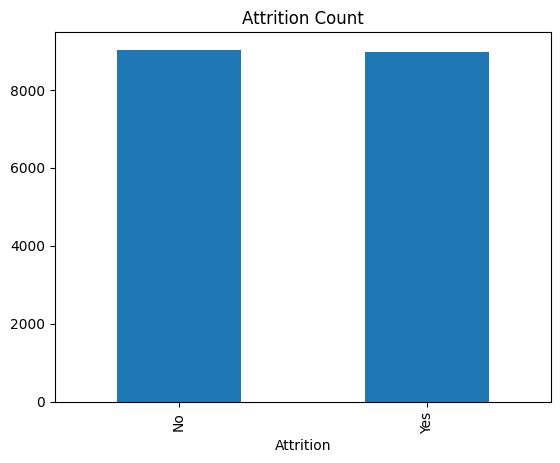

In [8]:
import matplotlib.pyplot as plt

# Attrition count plot
df['Attrition'].value_counts().plot(kind='bar')
plt.title("Attrition Count")
plt.show()

In [10]:
df.to_csv("clean_attrition.csv", index=False)